In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os
import json 

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
import pandas as pd

path = '/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/Data_Split/' 

# โหลดไฟล์
X_train = pd.read_csv(f'{path}X_train_90.csv')
X_test = pd.read_csv(f'{path}X_test_10.csv')
y_train = pd.read_csv(f'{path}y_train_90.csv').squeeze()
y_test = pd.read_csv(f'{path}y_test_10.csv').squeeze()

print("✅ โหลดชุดข้อมูล 90:10 เรียบร้อย!")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

✅ โหลดชุดข้อมูล 90:10 เรียบร้อย!
Train shape: (9000, 20)
Test shape: (1000, 20)


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# อัปเดตฟังก์ชันนี้ใหม่ ให้คืนค่า metrics ครบ 5 ตัว (Loss + 4 Metrics)
def create_dnn_model(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(16, activation='relu'),
        Dropout(0.2),
        
        Dense(1, activation='sigmoid')
    ])
    
    # ตรงนี้ค่ะที่เพิ่ม metrics เข้าไปให้ครบ
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy', 
            tf.keras.metrics.Precision(name='precision'), 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    
    return model

------------------------------
Baseline Model: Deep Neural Network (DNN)
------------------------------
Start Cross-Validation (Baseline)...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: Val Accuracy = 0.8000 (Recall: 0.0000)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: Val Accuracy = 0.8000 (Recall: 0.0000)


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: Val Accuracy = 0.8000 (Recall: 0.0000)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: Val Accuracy = 0.8000 (Recall: 0.0000)
------------------------------
>> Average CV Accuracy: 0.8000 (± 0.0000)
>> 🏆 Best Model Found in Fold: 1 (Score: 0.8000)
------------------------------

TEST SET PERFORMANCE (Baseline DNN - Fold 1)
Accuracy:  0.8000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4846
--------------------------------------------------
TP: 0 | TN: 800 | FP: 0 | FN: 200


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


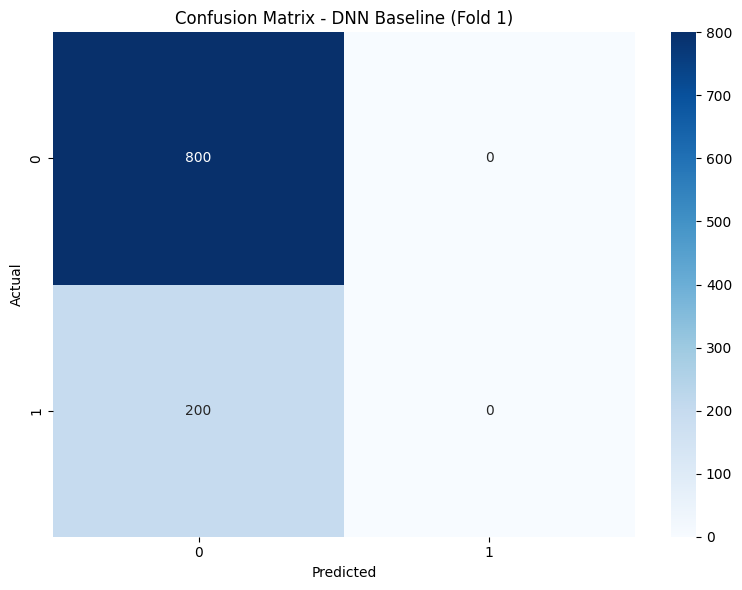

✓ Saved Best Model: dnn/models/DNN_baseline_bestfold.h5


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่า (Baseline - Updated)
# ==========================================
print("-" * 30)
print('Baseline Model: Deep Neural Network (DNN)')
print("-" * 30)

# ล็อค Random Seed
tf.random.set_seed(42)
np.random.seed(42)

# (สมมติว่า create_dnn_model ถูกประกาศไว้แล้วแบบ 5 metrics ตามที่แก้ไป)

# เตรียมตัวแปรเก็บ "ผู้ชนะ"
best_model_dnn_base = None
best_score_dnn_base = 0
best_fold_idx_dnn_base = -1
best_history_base = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation (Baseline)...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล (Baseline ไม่ทำ Sampling)
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.3 เทรนโมเดล
    history = model.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=100,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.4 สอบย่อย (Validate) - แก้ตรงนี้ค่ะ! รับค่า 5 ตัวให้ครบ
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.5 คัดเลือกผู้ชนะ
    if accuracy > best_score_dnn_base:
        best_score_dnn_base = accuracy
        best_model_dnn_base = model
        best_fold_idx_dnn_base = fold
        best_history_base = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_base} (Score: {best_score_dnn_base:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_base.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (Baseline DNN - Fold {best_fold_idx_dnn_base})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - DNN Baseline (Fold {best_fold_idx_dnn_base})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_baseline.png', dpi=300)
plt.show()

# 4.2 Dict Results
dnn_baseline_results = {
    'Model': 'DNN',
    'Sampling': 'None (Baseline)',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_base.save('dnn/models/DNN_baseline_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_baseline_bestfold.h5")

------------------------------
DNN + SMOTE (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: Val Accuracy = 0.4283 (Recall: 0.6389)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: Val Accuracy = 0.5444 (Recall: 0.4444)


...

Fold 3: Val Accuracy = 0.5706 (Recall: 0.4194)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: Val Accuracy = 0.4028 (Recall: 0.6056)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: Val Accuracy = 0.5789 (Recall: 0.3250)
------------------------------
>> Average CV Accuracy: 0.5050 (± 0.0744)
>> 🏆 Best Model Found in Fold: 5 (Score: 0.5789)
------------------------------

TEST SET PERFORMANCE (DNN + SMOTE - Fold 5)
Accuracy:  0.5600
Precision: 0.1970
Recall:    0.3900
F1-Score:  0.2617
ROC-AUC:   0.4910
--------------------------------------------------
TP: 78 | TN: 482 | FP: 318 | FN: 122


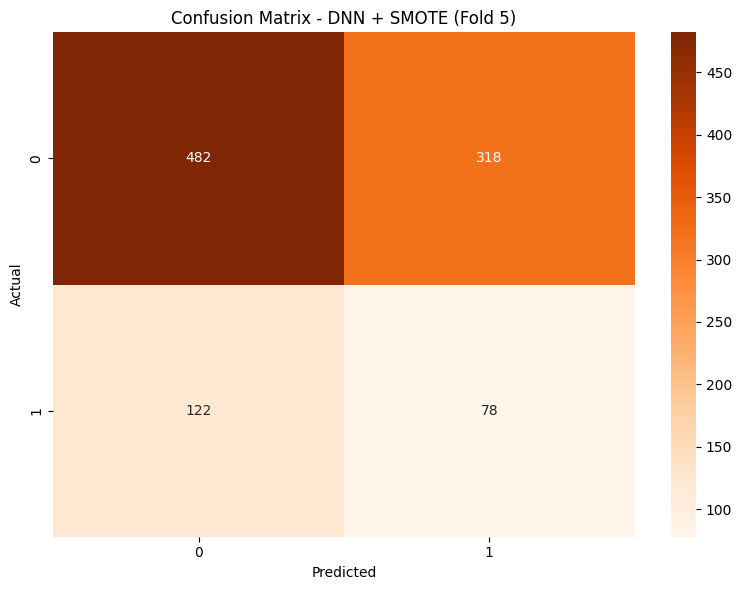

✓ Saved Best Model: dnn/models/DNN_smote_bestfold.h5


In [5]:
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + SMOTE)
# ==========================================
print("-" * 30)
print('DNN + SMOTE (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_smote = None
best_score_dnn_smote = 0
best_fold_idx_dnn_smote = -1
best_history_smote = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ SMOTE (Standard)
    # ทำเฉพาะ Training Set เท่านั้น! ห้ามทำกับ Validation/Test
    smote = SMOTE(random_state=42)
    X_fold_train_res, y_fold_train_res = smote.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดลใหม่ (ต้อง build ใหม่ทุกรอบ เพื่อ reset weight)
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0 # ปิด verbose ให้สะอาดตา
    )
    
    # 2.5 สอบย่อย (Validate)
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_smote:
        best_score_dnn_smote = accuracy
        best_model_dnn_smote = model
        best_fold_idx_dnn_smote = fold
        best_history_smote = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_smote} (Score: {best_score_dnn_smote:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_smote.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + SMOTE - Fold {best_fold_idx_dnn_smote})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + SMOTE (Fold {best_fold_idx_dnn_smote})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
# สร้างโฟลเดอร์ถ้ายังไม่มี
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_smote.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_smote_results = {
    'Model': 'DNN',
    'Sampling': f'SMOTE (Fold {best_fold_idx_dnn_smote})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_smote.save('dnn/models/DNN_smote_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_smote_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


------------------------------
DNN + ADASYN (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


Fold 1: Val Accuracy = 0.6561 (Recall: 0.2778)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: Val Accuracy = 0.6322 (Recall: 0.2833)


...

Fold 3: Val Accuracy = 0.5367 (Recall: 0.4389)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: Val Accuracy = 0.3933 (Recall: 0.7056)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: Val Accuracy = 0.4394 (Recall: 0.6389)
------------------------------
>> Average CV Accuracy: 0.5316 (± 0.1032)
>> 🏆 Best Model Found in Fold: 1 (Score: 0.6561)
------------------------------

TEST SET PERFORMANCE (DNN + ADASYN - Fold 1)
Accuracy:  0.6190
Precision: 0.1733
Recall:    0.2400
F1-Score:  0.2013
ROC-AUC:   0.4926
--------------------------------------------------
TP: 48 | TN: 571 | FP: 229 | FN: 152


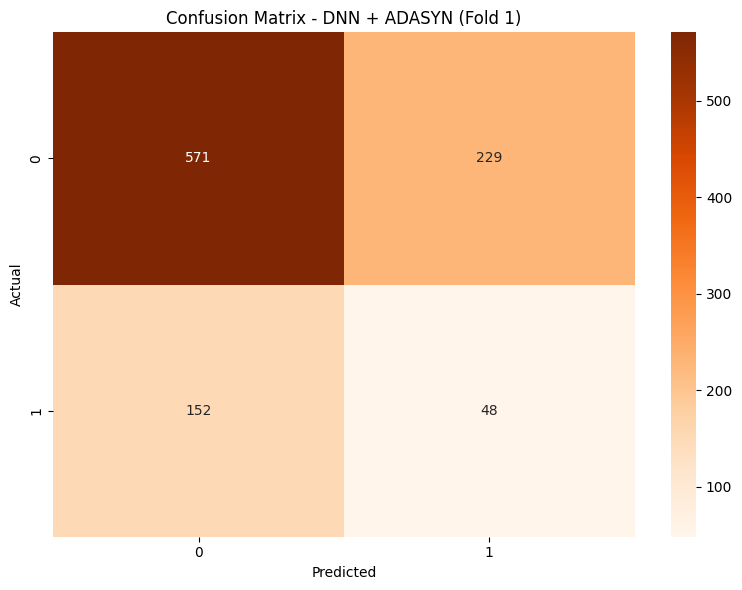

✓ Saved Best Model: dnn/models/DNN_adasyn_bestfold.h5


In [6]:
from imblearn.over_sampling import ADASYN
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + ADASYN)
# ==========================================
print("-" * 30)
print('DNN + ADASYN (Pick Best Fold)')
print("-" * 30)

# ต้องมั่นใจว่าฟังก์ชัน create_dnn_model ถูกรันไว้แล้วนะคะ (จากโค้ด Baseline ของตัวเอง)

best_model_dnn_adasyn = None
best_score_dnn_adasyn = 0
best_fold_idx_dnn_adasyn = -1
best_history_adasyn = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูลตาม Index
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ ADASYN (ทำเฉพาะ Training Set!)
    adasyn = ADASYN(random_state=42)
    X_fold_train_res, y_fold_train_res = adasyn.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดลใหม่ (Reset Weight ทุกรอบ)
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks สำหรับ Fold นี้
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    # หมายเหตุ: batch_size อาจต้องปรับถ้า RAM ไม่พอ (เช่น 64, 128)
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50, # ลดรอบลงหน่อยเพราะมี Early Stopping ช่วย
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0 # ปิด verbose เพื่อไม่ให้รกหน้าจอ
    )
    
    # 2.5 สอบย่อย (Validate)
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 คัดเลือกผู้ชนะ (ใช้ Accuracy เป็นเกณฑ์ หรือจะเปลี่ยนเป็น Recall ก็ได้)
    if accuracy > best_score_dnn_adasyn:
        best_score_dnn_adasyn = accuracy
        best_model_dnn_adasyn = model
        best_fold_idx_dnn_adasyn = fold
        best_history_adasyn = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_adasyn} (Score: {best_score_dnn_adasyn:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_adasyn.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + ADASYN - Fold {best_fold_idx_dnn_adasyn})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + ADASYN (Fold {best_fold_idx_dnn_adasyn})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_adasyn.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_adasyn_results = {
    'Model': 'DNN',
    'Sampling': f'ADASYN (Fold {best_fold_idx_dnn_adasyn})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model (.h5 for Keras)
best_model_dnn_adasyn.save('dnn/models/DNN_adasyn_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_adasyn_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


------------------------------
DNN + RandomUnderSampler (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


Fold 1: Val Accuracy = 0.5283 (Recall: 0.5083)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: Val Accuracy = 0.5650 (Recall: 0.3500)


...

Fold 3: Val Accuracy = 0.4228 (Recall: 0.6250)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: Val Accuracy = 0.7100 (Recall: 0.1333)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: Val Accuracy = 0.5956 (Recall: 0.3417)
------------------------------
>> Average CV Accuracy: 0.5643 (± 0.0933)
>> 🏆 Best Model Found in Fold: 4 (Score: 0.7100)
------------------------------

TEST SET PERFORMANCE (DNN + RandomUnderSampler - Fold 4)
Accuracy:  0.6980
Precision: 0.1304
Recall:    0.0900
F1-Score:  0.1065
ROC-AUC:   0.4753
--------------------------------------------------
TP: 18 | TN: 680 | FP: 120 | FN: 182


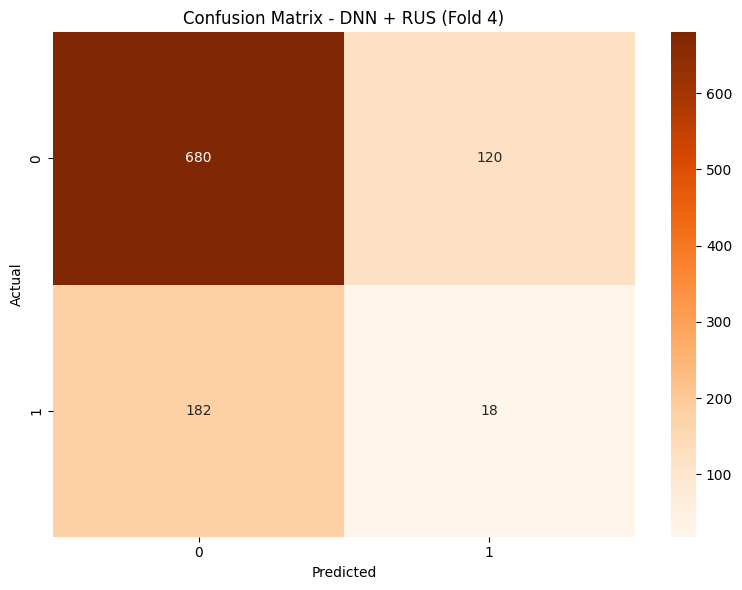

✓ Saved Best Model: dnn/models/DNN_rus_bestfold.h5


In [7]:
from imblearn.under_sampling import RandomUnderSampler
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + RandomUnderSampler)
# ==========================================
print("-" * 30)
print('DNN + RandomUnderSampler (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_rus = None
best_score_dnn_rus = 0
best_fold_idx_dnn_rus = -1
best_history_rus = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ RandomUnderSampler
    # สุ่มลบข้อมูล Majority ทิ้งจนเท่ากับ Minority
    rus = RandomUnderSampler(random_state=42)
    X_fold_train_res, y_fold_train_res = rus.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.5 สอบย่อย (Validate) - รับค่าครบ 5 ตัวแล้ว!
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_rus:
        best_score_dnn_rus = accuracy
        best_model_dnn_rus = model
        best_fold_idx_dnn_rus = fold
        best_history_rus = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_rus} (Score: {best_score_dnn_rus:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_rus.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + RandomUnderSampler - Fold {best_fold_idx_dnn_rus})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + RUS (Fold {best_fold_idx_dnn_rus})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_rus.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_rus_results = {
    'Model': 'DNN',
    'Sampling': f'RandomUnderSampler (Fold {best_fold_idx_dnn_rus})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_rus.save('dnn/models/DNN_rus_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_rus_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


------------------------------
DNN + NearMiss (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


Fold 1: Val Accuracy = 0.6156 (Recall: 0.3444)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2: Val Accuracy = 0.7478 (Recall: 0.1028)


...

Fold 3: Val Accuracy = 0.6261 (Recall: 0.2861)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: Val Accuracy = 0.5694 (Recall: 0.3417)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: Val Accuracy = 0.7056 (Recall: 0.1667)
------------------------------
>> Average CV Accuracy: 0.6529 (± 0.0646)
>> 🏆 Best Model Found in Fold: 2 (Score: 0.7478)
------------------------------

TEST SET PERFORMANCE (DNN + NearMiss - Fold 2)
Accuracy:  0.7520
Precision: 0.2447
Recall:    0.1150
F1-Score:  0.1565
ROC-AUC:   0.5128
--------------------------------------------------
TP: 23 | TN: 729 | FP: 71 | FN: 177


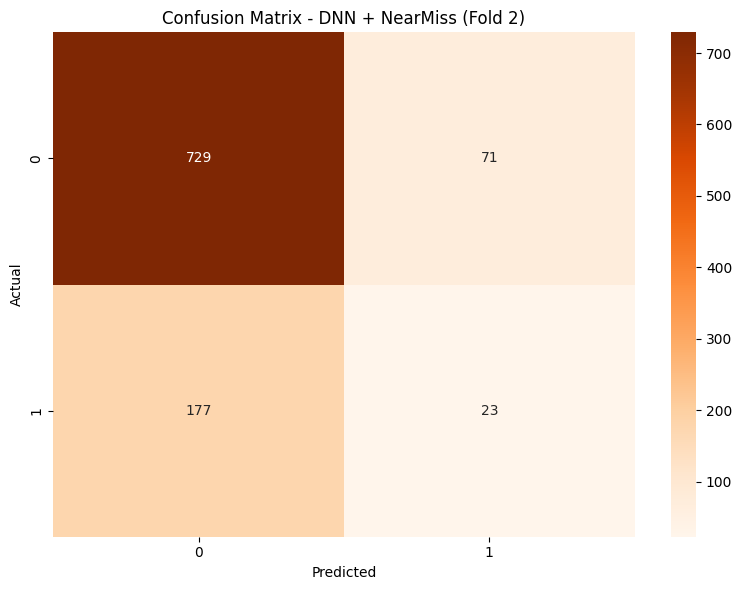

✓ Saved Best Model: dnn/models/DNN_nearmiss_bestfold.h5


In [8]:
from imblearn.under_sampling import NearMiss
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + NearMiss)
# ==========================================
print("-" * 30)
print('DNN + NearMiss (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_nm = None
best_score_dnn_nm = 0
best_fold_idx_dnn_nm = -1
best_history_nm = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ NearMiss
    # version=1 (Default): เลือก Majority ที่อยู่ใกล้ Minority ที่สุด
    nm = NearMiss(version=1)
    X_fold_train_res, y_fold_train_res = nm.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.5 สอบย่อย (Validate) - รับค่าครบ 5 ตัว
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_nm:
        best_score_dnn_nm = accuracy
        best_model_dnn_nm = model
        best_fold_idx_dnn_nm = fold
        best_history_nm = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_nm} (Score: {best_score_dnn_nm:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_nm.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + NearMiss - Fold {best_fold_idx_dnn_nm})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + NearMiss (Fold {best_fold_idx_dnn_nm})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_nearmiss.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_nearmiss_results = {
    'Model': 'DNN',
    'Sampling': f'NearMiss (Fold {best_fold_idx_dnn_nm})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_nm.save('dnn/models/DNN_nearmiss_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_nearmiss_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


------------------------------
DNN + ClusterCentroids (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1: Val Accuracy = 0.7633 (Recall: 0.0639)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


...

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4: Val Accuracy = 0.6489 (Recall: 0.2917)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5: Val Accuracy = 0.5706 (Recall: 0.3667)
------------------------------
>> Average CV Accuracy: 0.6713 (± 0.0750)
>> 🏆 Best Model Found in Fold: 1 (Score: 0.7633)
------------------------------

TEST SET PERFORMANCE (DNN + ClusterCentroids - Fold 1)
Accuracy:  0.7510
Precision: 0.0984
Recall:    0.0300
F1-Score:  0.0460
ROC-AUC:   0.4844
--------------------------------------------------
TP: 6 | TN: 745 | FP: 55 | FN: 194


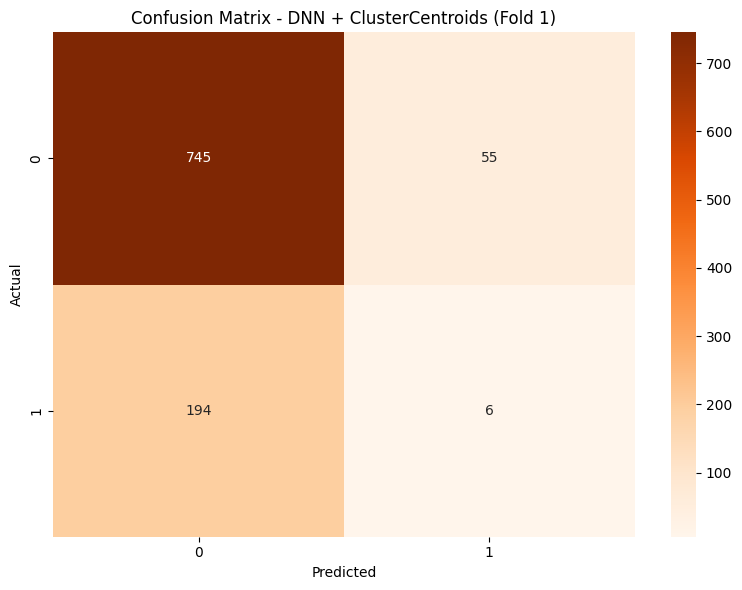

✓ Saved Best Model: dnn/models/DNN_cc_bestfold.h5


In [9]:
from imblearn.under_sampling import ClusterCentroids
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + ClusterCentroids)
# ==========================================
print("-" * 30)
print('DNN + ClusterCentroids (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_cc = None
best_score_dnn_cc = 0
best_fold_idx_dnn_cc = -1
best_history_cc = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("Warning: This might take a while due to clustering calculations...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ ClusterCentroids
    # ยุบรวมข้อมูล Majority ให้เหลือแค่จุด Centroid
    cc = ClusterCentroids(random_state=42)
    X_fold_train_res, y_fold_train_res = cc.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.5 สอบย่อย (Validate) - รับค่าครบ 5 ตัว
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_cc:
        best_score_dnn_cc = accuracy
        best_model_dnn_cc = model
        best_fold_idx_dnn_cc = fold
        best_history_cc = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_cc} (Score: {best_score_dnn_cc:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_cc.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + ClusterCentroids - Fold {best_fold_idx_dnn_cc})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + ClusterCentroids (Fold {best_fold_idx_dnn_cc})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_cc.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_cc_results = {
    'Model': 'DNN',
    'Sampling': f'ClusterCentroids (Fold {best_fold_idx_dnn_cc})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_cc.save('dnn/models/DNN_cc_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_cc_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
DNN + SMOTETomek (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


Fold 1: Val Accuracy = 0.6333 (Recall: 0.3056)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.5478 (Recall: 0.4278)


...

Fold 3: Val Accuracy = 0.5800 (Recall: 0.3361)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.4506 (Recall: 0.5944)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.6044 (Recall: 0.3250)
------------------------------
>> Average CV Accuracy: 0.5632 (± 0.0630)
>> 🏆 Best Model Found in Fold: 1 (Score: 0.6333)
------------------------------

TEST SET PERFORMANCE (DNN + SMOTETomek - Fold 1)
Accuracy:  0.6150
Precision: 0.1967
Recall:    0.3000
F1-Score:  0.2376
ROC-AUC:   0.4995
--------------------------------------------------
TP: 60 | TN: 555 | FP: 245 | FN: 140


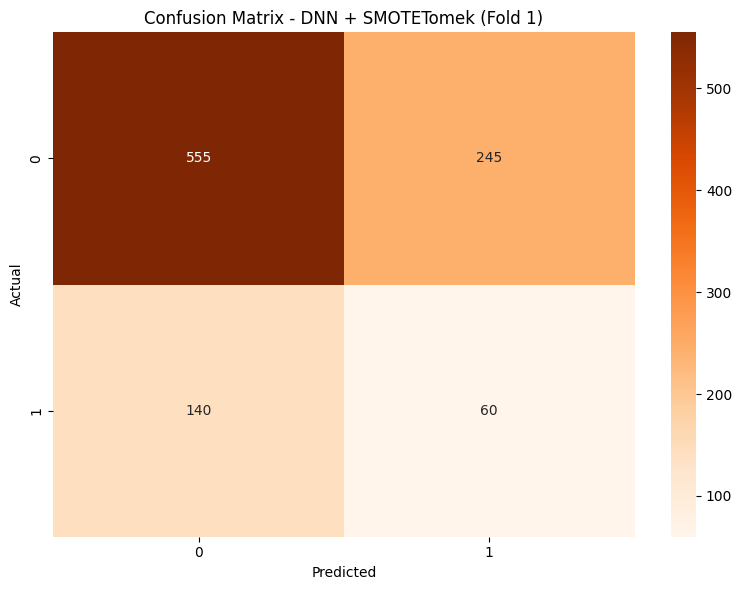

✓ Saved Best Model: dnn/models/DNN_smotetomek_bestfold.h5


In [10]:
from imblearn.combine import SMOTETomek
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + SMOTETomek)
# ==========================================
print("-" * 30)
print('DNN + SMOTETomek (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_smt = None
best_score_dnn_smt = 0
best_fold_idx_dnn_smt = -1
best_history_smt = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ SMOTETomek
    # (เพิ่มด้วย SMOTE แล้วตัดขอบด้วย Tomek Links)
    smt = SMOTETomek(random_state=42)
    X_fold_train_res, y_fold_train_res = smt.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.5 สอบย่อย (Validate) - รับค่าครบ 5 ตัว
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_smt:
        best_score_dnn_smt = accuracy
        best_model_dnn_smt = model
        best_fold_idx_dnn_smt = fold
        best_history_smt = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_smt} (Score: {best_score_dnn_smt:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_smt.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + SMOTETomek - Fold {best_fold_idx_dnn_smt})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + SMOTETomek (Fold {best_fold_idx_dnn_smt})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_smotetomek.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_smt_results = {
    'Model': 'DNN',
    'Sampling': f'SMOTETomek (Fold {best_fold_idx_dnn_smt})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_smt.save('dnn/models/DNN_smotetomek_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_smotetomek_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

------------------------------
DNN + SMOTEENN (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


Fold 1: Val Accuracy = 0.2000 (Recall: 1.0000)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 2: Val Accuracy = 0.2006 (Recall: 1.0000)


...

Fold 3: Val Accuracy = 0.2000 (Recall: 1.0000)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 4: Val Accuracy = 0.2006 (Recall: 0.9917)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and i

Fold 5: Val Accuracy = 0.2000 (Recall: 0.9972)
------------------------------
>> Average CV Accuracy: 0.2002 (± 0.0003)
>> 🏆 Best Model Found in Fold: 2 (Score: 0.2006)
------------------------------

TEST SET PERFORMANCE (DNN + SMOTEENN - Fold 2)
Accuracy:  0.2000
Precision: 0.2000
Recall:    1.0000
F1-Score:  0.3333
ROC-AUC:   0.4787
--------------------------------------------------
TP: 200 | TN: 0 | FP: 800 | FN: 0


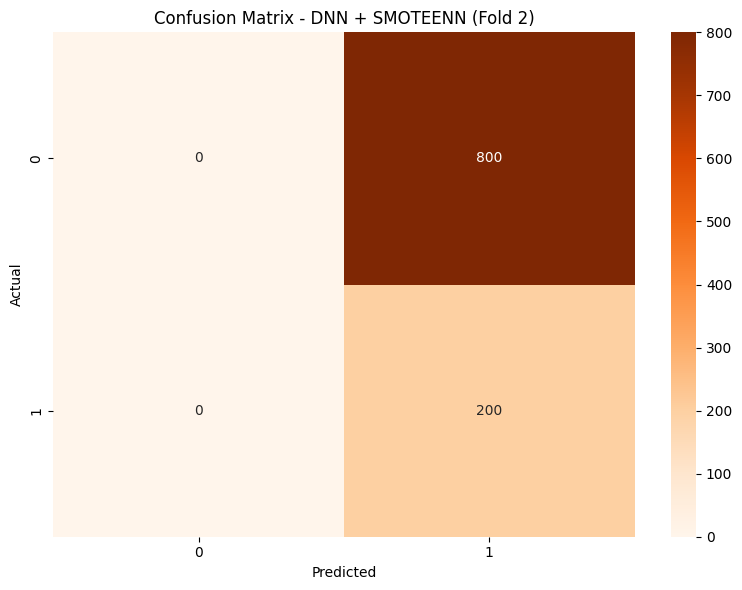

✓ Saved Best Model: dnn/models/DNN_smoteenn_bestfold.h5


In [11]:
from imblearn.combine import SMOTEENN
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + SMOTEENN)
# ==========================================
print("-" * 30)
print('DNN + SMOTEENN (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_sme = None
best_score_dnn_sme = 0
best_fold_idx_dnn_sme = -1
best_history_sme = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้ SMOTEENN
    # (เพิ่มด้วย SMOTE แล้วลบ Noise แบบเข้มข้นด้วย ENN)
    sme = SMOTEENN(random_state=42)
    X_fold_train_res, y_fold_train_res = sme.fit_resample(X_fold_train, y_fold_train)
    
    # 2.3 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.5 สอบย่อย (Validate) - รับค่าครบ 5 ตัว
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_sme:
        best_score_dnn_sme = accuracy
        best_model_dnn_sme = model
        best_fold_idx_dnn_sme = fold
        best_history_sme = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_sme} (Score: {best_score_dnn_sme:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_sme.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + SMOTEENN - Fold {best_fold_idx_dnn_sme})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + SMOTEENN (Fold {best_fold_idx_dnn_sme})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_smoteenn.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_sme_results = {
    'Model': 'DNN',
    'Sampling': f'SMOTEENN (Fold {best_fold_idx_dnn_sme})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_sme.save('dnn/models/DNN_smoteenn_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_smoteenn_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

------------------------------
DNN + ADASYN + Tomek Links (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


Fold 1: Val Accuracy = 0.5594 (Recall: 0.3972)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 2: Val Accuracy = 0.5211 (Recall: 0.5361)


...

Fold 3: Val Accuracy = 0.6206 (Recall: 0.3444)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 4: Val Accuracy = 0.3939 (Recall: 0.7083)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 5: Val Accuracy = 0.6094 (Recall: 0.3250)
------------------------------
>> Average CV Accuracy: 0.5409 (± 0.0817)
>> 🏆 Best Model Found in Fold: 3 (Score: 0.6206)
------------------------------

TEST SET PERFORMANCE (DNN + ADASYN + Tomek - Fold 3)
Accuracy:  0.6080
Precision: 0.1981
Recall:    0.3150
F1-Score:  0.2432
ROC-AUC:   0.4996
--------------------------------------------------
TP: 63 | TN: 545 | FP: 255 | FN: 137


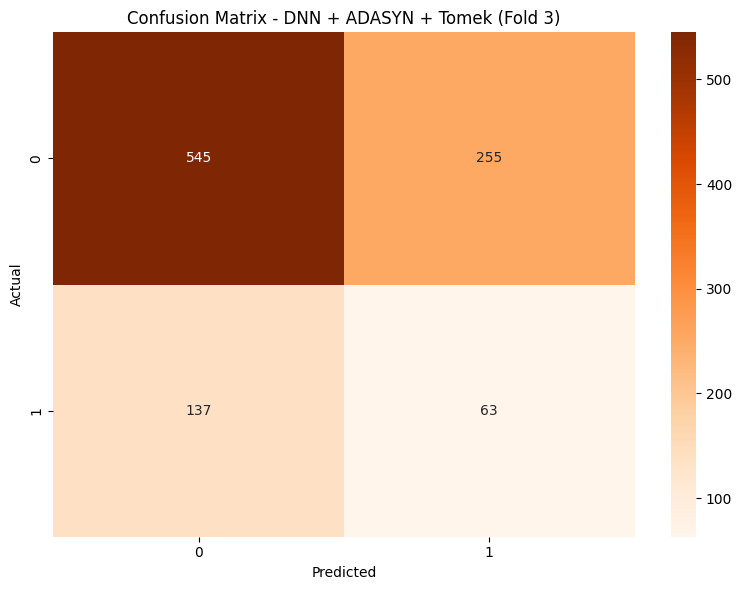

✓ Saved Best Model: dnn/models/DNN_adasyn_tomek_bestfold.h5


In [12]:
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + ADASYN + Tomek)
# ==========================================
print("-" * 30)
print('DNN + ADASYN + Tomek Links (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_ada_tomek = None
best_score_dnn_ada_tomek = 0
best_fold_idx_dnn_ada_tomek = -1
best_history_ada_tomek = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้แบบ Pipeline (Manual Chain)
    # Step 1: ADASYN (สร้างข้อมูลเทียมเน้นจุดยาก)
    ada = ADASYN(random_state=42)
    X_res_step1, y_res_step1 = ada.fit_resample(X_fold_train, y_fold_train)
    
    # Step 2: Tomek Links (ลบตัวที่อยู่ใกล้กันเกินไป)
    tl = TomekLinks()
    X_fold_train_res, y_fold_train_res = tl.fit_resample(X_res_step1, y_res_step1)
    
    # 2.3 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.5 สอบย่อย (Validate) - รับค่าครบ 5 ตัว
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_ada_tomek:
        best_score_dnn_ada_tomek = accuracy
        best_model_dnn_ada_tomek = model
        best_fold_idx_dnn_ada_tomek = fold
        best_history_ada_tomek = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_ada_tomek} (Score: {best_score_dnn_ada_tomek:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_ada_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + ADASYN + Tomek - Fold {best_fold_idx_dnn_ada_tomek})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + ADASYN + Tomek (Fold {best_fold_idx_dnn_ada_tomek})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_adasyn_tomek.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_ada_tomek_results = {
    'Model': 'DNN',
    'Sampling': f'ADASYN + Tomek (Fold {best_fold_idx_dnn_ada_tomek})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_ada_tomek.save('dnn/models/DNN_adasyn_tomek_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_adasyn_tomek_bestfold.h5")

/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

------------------------------
DNN + Borderline SMOTE v.2 + Tomek (Pick Best Fold)
------------------------------
Start Cross-Validation...
------------------------------


Fold 1: Val Accuracy = 0.5906 (Recall: 0.3528)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 2: Val Accuracy = 0.3617 (Recall: 0.7528)


...

Fold 3: Val Accuracy = 0.4483 (Recall: 0.5556)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 4: Val Accuracy = 0.5506 (Recall: 0.4556)


/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/tanananyathongkum/Jenny/Project/Heart Disease/PJ 2/env/lib/python3.9/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the 

Fold 5: Val Accuracy = 0.5578 (Recall: 0.3889)
------------------------------
>> Average CV Accuracy: 0.5018 (± 0.0847)
>> 🏆 Best Model Found in Fold: 1 (Score: 0.5906)
------------------------------

TEST SET PERFORMANCE (DNN + Borderline-2 + Tomek - Fold 1)
Accuracy:  0.5790
Precision: 0.1797
Recall:    0.3100
F1-Score:  0.2275
ROC-AUC:   0.4673
--------------------------------------------------
TP: 62 | TN: 517 | FP: 283 | FN: 138


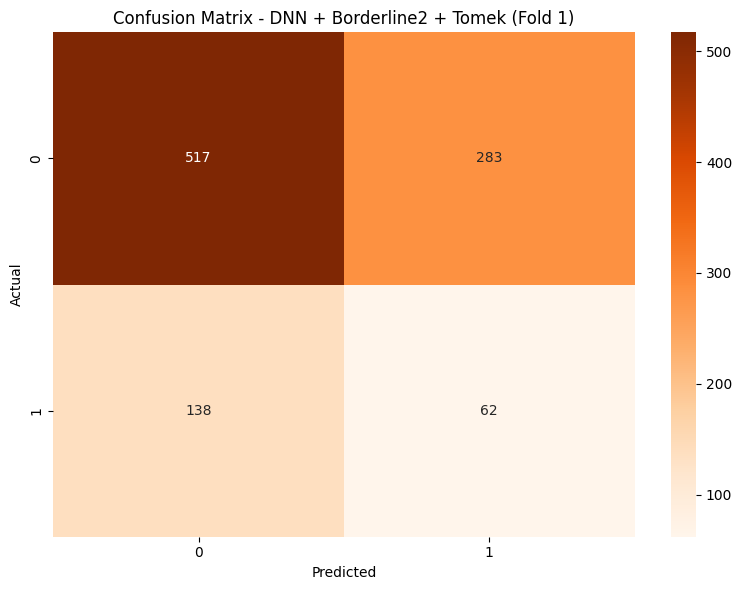

✓ Saved Best Model: dnn/models/DNN_borderline2_tomek_bestfold.h5


In [13]:
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.under_sampling import TomekLinks
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import os
import joblib

# ==========================================
# 🔍 ส่วนที่ 1: ตั้งค่าและเตรียมตัวแปร (DNN + Borderline-2 + Tomek)
# ==========================================
print("-" * 30)
print('DNN + Borderline SMOTE v.2 + Tomek (Pick Best Fold)')
print("-" * 30)

# เตรียมตัวแปรเก็บ Best Model
best_model_dnn_bl_tomek = None
best_score_dnn_bl_tomek = 0
best_fold_idx_dnn_bl_tomek = -1
best_history_bl_tomek = None

# สร้างตัวแบ่งข้อมูล
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"Start Cross-Validation...")
print("-" * 30)

# ==========================================
# 🔄 ส่วนที่ 2: วนลูป 5 รอบ (Training Loop)
# ==========================================
for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train.values.ravel()), 1):
    
    # 2.1 ดึงข้อมูล
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.values.ravel()[train_idx], y_train.values.ravel()[val_idx]
    
    # 2.2 ประยุกต์ใช้แบบ Pipeline
    # Step 1: Borderline SMOTE v.2 (เน้นขอบ + ดูเพื่อนบ้านต่างสี)
    bl_smote = BorderlineSMOTE(kind='borderline-2', random_state=42)
    X_res_step1, y_res_step1 = bl_smote.fit_resample(X_fold_train, y_fold_train)
    
    # Step 2: Tomek Links (คลีนพื้นที่ทับซ้อน)
    tl = TomekLinks()
    X_fold_train_res, y_fold_train_res = tl.fit_resample(X_res_step1, y_res_step1)
    
    # 2.3 สร้างโมเดลใหม่
    model = create_dnn_model(X_fold_train_res.shape[1])
    
    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=0)
    
    # 2.4 เทรนโมเดล
    history = model.fit(
        X_fold_train_res, y_fold_train_res,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping, reduce_lr],
        verbose=0
    )
    
    # 2.5 สอบย่อย (Validate) - รับค่าครบ 5 ตัว
    loss, accuracy, precision, recall, auc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
    cv_scores.append(accuracy)
    
    print(f"Fold {fold}: Val Accuracy = {accuracy:.4f} (Recall: {recall:.4f})")
    
    # 2.6 เก็บโมเดลที่ดีที่สุด
    if accuracy > best_score_dnn_bl_tomek:
        best_score_dnn_bl_tomek = accuracy
        best_model_dnn_bl_tomek = model
        best_fold_idx_dnn_bl_tomek = fold
        best_history_bl_tomek = history

print("-" * 30)
print(f'>> Average CV Accuracy: {np.mean(cv_scores):.4f} (± {np.std(cv_scores):.4f})')
print(f'>> 🏆 Best Model Found in Fold: {best_fold_idx_dnn_bl_tomek} (Score: {best_score_dnn_bl_tomek:.4f})')
print("-" * 30)

# ==========================================
# 📊 ส่วนที่ 3: วัดผลจริง (Test Set Evaluation)
# ==========================================
# ใช้โมเดลที่ดีที่สุดทำนาย
y_pred_proba = best_model_dnn_bl_tomek.predict(X_test, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# คำนวณค่าทางสถิติ
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_pred_proba)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# แสดงผลลัพธ์
print("\n" + "=" * 50)
print(f"TEST SET PERFORMANCE (DNN + Borderline-2 + Tomek - Fold {best_fold_idx_dnn_bl_tomek})")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print("-" * 50)
print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")
print("=" * 50)

# ==========================================
# 🎨 ส่วนที่ 4: บันทึกผล
# ==========================================
# 4.1 Confusion Matrix Image
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges')
plt.title(f'Confusion Matrix - DNN + Borderline2 + Tomek (Fold {best_fold_idx_dnn_bl_tomek})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
os.makedirs('dnn/models', exist_ok=True)
plt.savefig('dnn/models/cm_dnn_borderline2_tomek.png', dpi=300)
plt.show()

# 4.2 Save Dict Results
dnn_bl_tomek_results = {
    'Model': 'DNN',
    'Sampling': f'Borderline-2 + Tomek (Fold {best_fold_idx_dnn_bl_tomek})',
    'CV_Accuracy': np.mean(cv_scores),
    'CV_Std': np.std(cv_scores),
    'Test_Accuracy': test_accuracy,
    'Precision': test_precision,
    'Recall': test_recall,
    'F1_Score': test_f1,
    'ROC_AUC': test_roc_auc,
    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
}

# 4.3 Save Model
best_model_dnn_bl_tomek.save('dnn/models/DNN_borderline2_tomek_bestfold.h5')
print(f"✓ Saved Best Model: dnn/models/DNN_borderline2_tomek_bestfold.h5")

🏆 FINAL COMPARISON TABLE - Deep Neural Network (Sorted by Recall)


,Model,Sampling,CV_Accuracy,CV_Std,Test_Accuracy,Precision,Recall,F1_Score,ROC_AUC,TP,TN,FP,FN
0,DNN,SMOTEENN (Fold 2),0.200222,0.000272,0.200,0.200000,1.000,0.333333,0.478656,200,0,800,0
1,DNN,SMOTE (Fold 5),0.505000,0.074351,0.560,0.196970,0.390,0.261745,0.491006,78,482,318,122
2,DNN,ADASYN + Tomek (Fold 3),0.540889,0.081720,0.608,0.198113,0.315,0.243243,0.499556,63,545,255,137
3,DNN,Borderline-2 + Tomek (Fold 1),0.501778,0.084716,0.579,0.179710,0.310,0.227523,0.467347,62,517,283,138
4,DNN,SMOTETomek (Fold 1),0.563222,0.062974,0.615,0.196721,0.300,0.237624,0.499506,60,555,245,140
5,DNN,ADASYN (Fold 1),0.531556,0.103212,0.619,0.173285,0.240,0.201258,0.492556,48,571,229,152
6,DNN,NearMiss (Fold 2),0.652889,0.064578,0.752,0.244681,0.115,0.156463,0.512806,23,729,71,177
7,DNN,RandomUnderSampler (Fold 4),0.564333,0.093304,0.698,0.130435,0.090,0.106509,0.475319,18,680,120,182
8,DNN,ClusterCentroids (Fold 1),0.671333,0.075012,0.751,0.098361,0.030,0.045977,0.484375,6,745,55,194
9,DNN,None (Baseline),0.800000,0.000000,0.800,0.000000,0.000,0.000000,0.484584,0,800,0,200



✓ Saved comparison table to: dnn/dnn_technique_comparison.csv


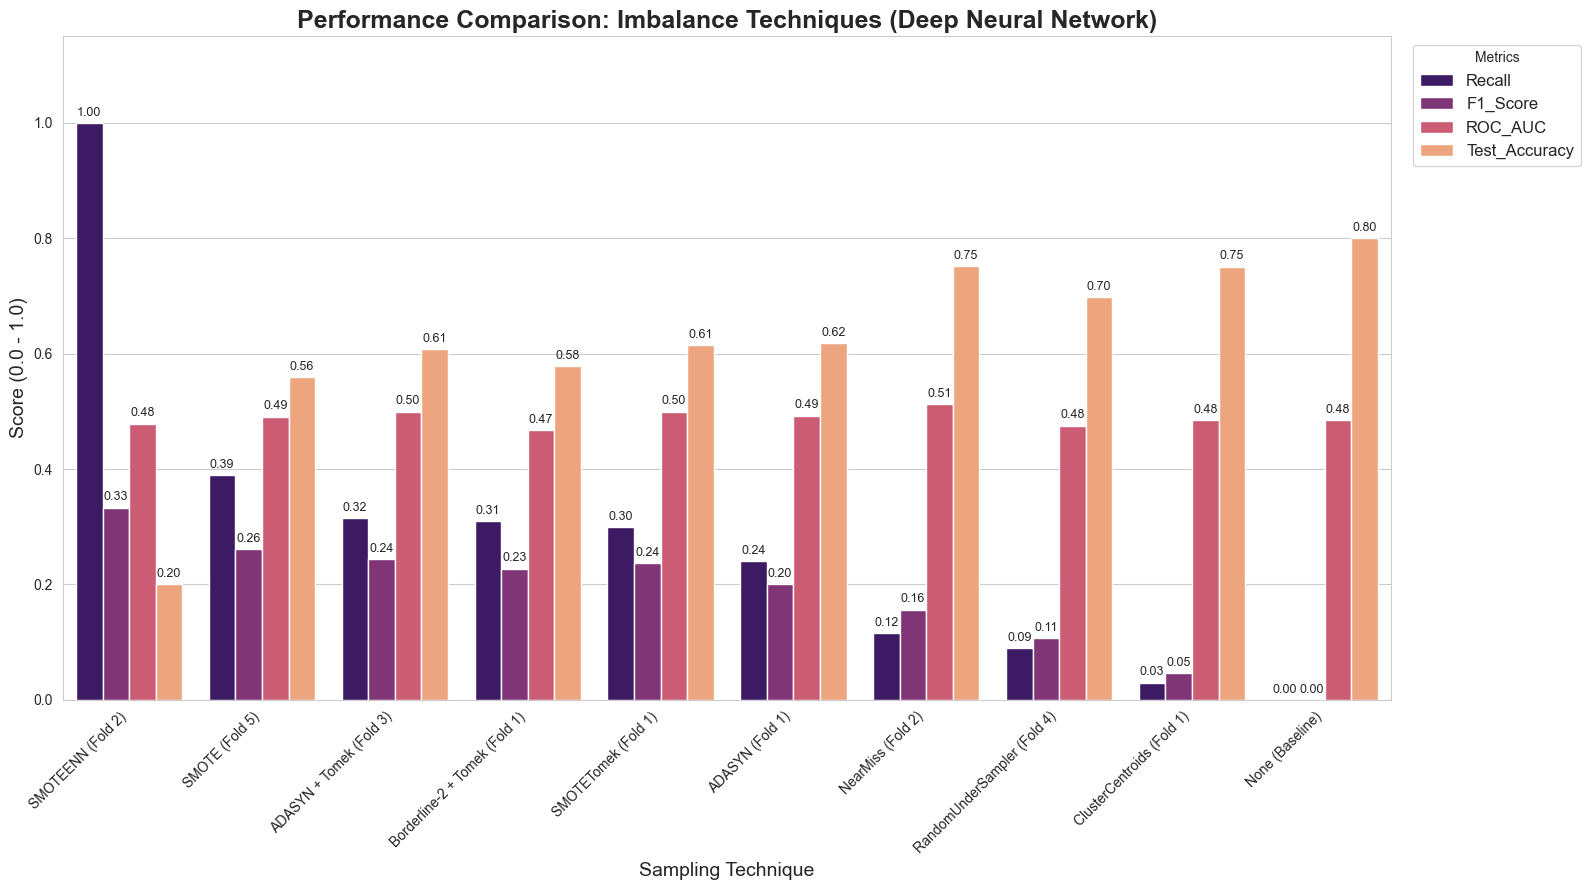

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 📊 ส่วนที่ 5: สรุปผลการทดลอง (Aggregation)
# ==========================================

# 1. รวม Dictionary ผลลัพธ์ทั้งหมดเข้าใน List เดียว
# (เช็คชื่อตัวแปรให้ตรงกับที่รันมานะคะ)
dnn_all_results = [
    dnn_baseline_results,   # Baseline (No Sampling)
    dnn_smote_results,      # SMOTE
    dnn_adasyn_results,     # ADASYN
    dnn_rus_results,        # RandomUnderSampler
    dnn_nearmiss_results,   # NearMiss
    dnn_cc_results,         # ClusterCentroids
    dnn_smt_results,        # SMOTETomek
    dnn_sme_results,        # SMOTEENN
    dnn_ada_tomek_results,  # ADASYN + Tomek
    dnn_bl_tomek_results    # Borderline-2 + Tomek
]

# 2. แปลงเป็น DataFrame
df_dnn_results = pd.DataFrame(dnn_all_results)

# 3. จัดเรียงลำดับ (Sort)
# เรียงตาม Recall (จากมากไปน้อย) เพราะงานการแพทย์เราไม่อยากหลุดคนป่วย
df_dnn_results = df_dnn_results.sort_values(by='Recall', ascending=False).reset_index(drop=True)

# 4. แสดงตารางผลลัพธ์
print("=" * 100)
print("🏆 FINAL COMPARISON TABLE - Deep Neural Network (Sorted by Recall)")
print("=" * 100)
display(df_dnn_results) # ถ้าใช้ Jupyter ให้ใช้ display() ถ้าใช้ Editor อื่นให้ใช้ print()

# 5. บันทึกตารางเป็นไฟล์ CSV
df_dnn_results.to_csv('dnn/dnn_technique_comparison.csv', index=False)
print(f"\n✓ Saved comparison table to: dnn/dnn_technique_comparison.csv")

# ==========================================
# 📈 ส่วนที่ 6: สร้างกราฟเปรียบเทียบ (Bar Chart)
# ==========================================
plt.figure(figsize=(16, 9))
sns.set_style("whitegrid")

# แปลงข้อมูลให้เหมาะกับการพลอต (Melt)
metrics_to_plot = ['Recall', 'F1_Score', 'ROC_AUC', 'Test_Accuracy']
df_melted = df_dnn_results.melt(id_vars='Sampling', value_vars=metrics_to_plot, 
                                var_name='Metric', value_name='Score')

# สร้าง Bar Plot
# palette='magma' เลือกสีโทนร้อนแรงให้สมกับเป็น Deep Learning 🔥
ax = sns.barplot(data=df_melted, x='Sampling', y='Score', hue='Metric', palette='magma')

# ตกแต่งกราฟ
plt.title('Performance Comparison: Imbalance Techniques (Deep Neural Network)', fontsize=18, fontweight='bold')
plt.ylabel('Score (0.0 - 1.0)', fontsize=14)
plt.xlabel('Sampling Technique', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12, title='Metrics')
plt.ylim(0, 1.15) # เผื่อที่ด้านบนไว้ใส่ตัวเลข

# ใส่ตัวเลขบนแท่งกราฟ
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9, rotation=0)

plt.tight_layout()

# บันทึกรูปกราฟ
plt.savefig('dnn/models/dnn_technique_comparison_chart.png', dpi=300)
plt.show()